# **Library**

In [ ]:
# IMPORT LIBRARY

import os
import cv2
import time
import shutil
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# **Data Wrangling**

## Gathering

In [ ]:
# Download dataset dari KaggleHub
dataset_path = kagglehub.dataset_download("prasadvpatil/mrl-dataset")
print("Dataset path:", dataset_path)

# Folder train
TRAIN_PATH = os.path.join(dataset_path, "train")

# Folder kelas
CLASSES = ["Closed_Eyes", "Open_Eyes"]  # 0 = Closed, 1 = Open
IMG_SIZE = (96, 96)

Using Colab cache for faster access to the 'mrl-dataset' dataset.
Dataset path: /kaggle/input/mrl-dataset


## Assessing

In [ ]:
# CEK JUMLAH DATA PER KELAS

for index, label in enumerate(CLASSES):
    folder_path = os.path.join(TRAIN_PATH, label)

    print(f"Label {index} = {label}")
    print("Path:", folder_path)
    print("Folder tersedia:", os.path.exists(folder_path))
    print("Jumlah file:", len(os.listdir(folder_path)))
    print("-" * 50)

Label 0 = Closed_Eyes
Path: /kaggle/input/mrl-dataset/train/Closed_Eyes
Folder tersedia: True
Jumlah file: 2000
--------------------------------------------------
Label 1 = Open_Eyes
Path: /kaggle/input/mrl-dataset/train/Open_Eyes
Folder tersedia: True
Jumlah file: 2000
--------------------------------------------------


In [ ]:
# MEMBUAT DATAFRAME METADATA

data = []

for label, class_name in enumerate(CLASSES):
    folder_path = os.path.join(TRAIN_PATH, class_name)

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        data.append({
            "image_path": img_path,
            "label": label,
            "class": "Closed" if label == 0 else "Open"
        })

df = pd.DataFrame(data)

print("Jumlah total data:", len(df))
display(df.head())
display(df["class"].value_counts())

Jumlah total data: 4000


,image_path,label,class
0,/kaggle/input/mrl-dataset/train/Closed_Eyes/s0...,0,Closed
1,/kaggle/input/mrl-dataset/train/Closed_Eyes/s0...,0,Closed
2,/kaggle/input/mrl-dataset/train/Closed_Eyes/s0...,0,Closed
3,/kaggle/input/mrl-dataset/train/Closed_Eyes/s0...,0,Closed
4,/kaggle/input/mrl-dataset/train/Closed_Eyes/s0...,0,Closed


,count
class,
Closed,2000
Open,2000


In [ ]:
# CEK MISSING VALUE DAN DUPLIKASI

print("Missing value:")
display(df.isnull().sum())

duplicate_count = df.duplicated(subset=["image_path"]).sum()
print("Jumlah duplikasi image_path:", duplicate_count)

Missing value:


,0
image_path,0
label,0
class,0


Jumlah duplikasi image_path: 0


In [ ]:
# CEK GAMBAR CORRUPT / GAGAL DIBACA

bad_images = []

for img_path in df["image_path"]:
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        bad_images.append(img_path)

print("Jumlah corrupt images:", len(bad_images))

Jumlah corrupt images: 0


In [ ]:
# CEK VARIASI UKURAN GAMBAR

image_shapes = []

for img_path in df["image_path"]:
    img = cv2.imread(img_path)

    if img is not None:
        image_shapes.append(img.shape)

image_shapes_df = pd.DataFrame(
    image_shapes,
    columns=["height", "width", "channel"]
)

print("Contoh ukuran gambar:")
display(image_shapes_df.head())

print("\nJumlah variasi ukuran gambar:")
display(image_shapes_df.value_counts().head())

Contoh ukuran gambar:


,height,width,channel
0,108,108,3
1,94,94,3
2,95,95,3
3,96,96,3
4,134,134,3



Jumlah variasi ukuran gambar:


,,,count
height,width,channel,
95,95,3,100
85,85,3,95
93,93,3,95
97,97,3,93
86,86,3,89


## Cleaning

In [ ]:
# CLEANING DATA
df_clean = df.copy()

# Menghapus gambar corrupt jika ditemukan
if len(bad_images) > 0:
    df_clean = df_clean[~df_clean["image_path"].isin(bad_images)].reset_index(drop=True)

# Menghapus duplikasi image_path jika ditemukan
df_clean = df_clean.drop_duplicates(subset=["image_path"]).reset_index(drop=True)

print("Jumlah data sebelum cleaning:", len(df))
print("Jumlah data setelah cleaning :", len(df_clean))

print("\nDistribusi kelas setelah cleaning:")
display(df_clean["class"].value_counts())

Jumlah data sebelum cleaning: 4000
Jumlah data setelah cleaning : 4000

Distribusi kelas setelah cleaning:


,count
class,
Closed,2000
Open,2000


# **Feature Engineering**

In [ ]:
# 96x96 pixel, grayscale, dan nilai pixel 0-1

IMG_SIZE = (96, 96)

def preprocess_image(img_path, target_size=IMG_SIZE):
    # Membaca gambar dalam mode grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    # Jika gambar gagal dibaca, fungsi akan mengembalikan None
    if img is None:
        return None

    # Resize gambar ke ukuran input model
    img = cv2.resize(img, target_size)

    # Normalisasi pixel dari rentang 0-255 menjadi 0-1
    img = img.astype("float32") / 255.0

    # Menambahkan channel agar bentuknya menjadi 96x96x1
    img = np.expand_dims(img, axis=-1)

    return img

In [ ]:
# Menerapkan preprocessing ke seluruh data yang sudah dibersihkan

images = []
labels = []
valid_paths = []

for _, row in df_clean.iterrows():
    img = preprocess_image(row["image_path"])

    if img is not None:
        images.append(img)
        labels.append(row["label"])
        valid_paths.append(row["image_path"])

images = np.array(images)
labels = np.array(labels)

print("Shape images:", images.shape)
print("Shape labels:", labels.shape)
print("Nilai minimum pixel:", images.min())
print("Nilai maksimum pixel:", images.max())

Shape images: (4000, 96, 96, 1)
Shape labels: (4000,)
Nilai minimum pixel: 0.0
Nilai maksimum pixel: 1.0


# Split Data

In [ ]:
# SPLIT DATA 70/15/15

# 70% train, 15% validation, 15% test

x_temp, x_test, y_temp, y_test = train_test_split(
    images,
    labels,
    test_size=0.15,
    random_state=42,
    stratify=labels
)

x_train, x_val, y_train, y_val = train_test_split(
    x_temp,
    y_temp,
    test_size=0.176,
    random_state=42,
    stratify=y_temp
)

total = len(images)

print(f"Total data     : {total}")
print(f"Train set      : {len(x_train)} ({len(x_train)/total*100:.1f}%)")
print(f"Validation set : {len(x_val)} ({len(x_val)/total*100:.1f}%)")
print(f"Test set       : {len(x_test)} ({len(x_test)/total*100:.1f}%)")

unique_train, counts_train = np.unique(y_train, return_counts=True)
unique_val, counts_val = np.unique(y_val, return_counts=True)
unique_test, counts_test = np.unique(y_test, return_counts=True)

print(f"\nDistribusi Train      — Closed: {counts_train[0]}, Open: {counts_train[1]}")
print(f"Distribusi Validation — Closed: {counts_val[0]}, Open: {counts_val[1]}")
print(f"Distribusi Test       — Closed: {counts_test[0]}, Open: {counts_test[1]}")

Total data     : 4000
Train set      : 2801 (70.0%)
Validation set : 599 (15.0%)
Test set       : 600 (15.0%)

Distribusi Train      — Closed: 1400, Open: 1401
Distribusi Validation — Closed: 300, Open: 299
Distribusi Test       — Closed: 300, Open: 300


# **Data Dictionary**

In [ ]:
# DATA DICTIONARY

data_dictionary = pd.DataFrame({
    "Kolom / Objek Data": [
        "image_path",
        "label",
        "class",
        "images",
        "labels",
        "x_train",
        "x_val",
        "x_test",
        "y_train",
        "y_val",
        "y_test"
    ],
    "Tipe Data": [
        "string",
        "integer",
        "string",
        "numpy array",
        "numpy array",
        "numpy array",
        "numpy array",
        "numpy array",
        "numpy array",
        "numpy array",
        "numpy array"
    ],
    "Deskripsi": [
        "Lokasi file gambar pada direktori dataset.",
        "Label numerik gambar. 0 = Closed, 1 = Open.",
        "Nama kelas gambar, yaitu Closed atau Open.",
        "Kumpulan gambar hasil feature engineering/preprocessing dengan ukuran 96x96, grayscale, dan nilai pixel 0-1.",
        "Kumpulan label numerik dari seluruh gambar.",
        "Subset gambar untuk data training sesuai split pipeline AI.",
        "Subset gambar untuk data validation yang digunakan dalam threshold analysis dan A/B testing.",
        "Subset gambar untuk data testing yang digunakan dalam evaluasi akhir model.",
        "Label untuk data training.",
        "Label untuk data validation.",
        "Label untuk data testing."
    ]
})

display(data_dictionary)

,Kolom / Objek Data,Tipe Data,Deskripsi
0,image_path,string,Lokasi file gambar pada direktori dataset.
1,label,integer,"Label numerik gambar. 0 = Closed, 1 = Open."
2,class,string,"Nama kelas gambar, yaitu Closed atau Open."
3,images,numpy array,Kumpulan gambar hasil feature engineering/prep...
4,labels,numpy array,Kumpulan label numerik dari seluruh gambar.
5,x_train,numpy array,Subset gambar untuk data training sesuai split...
6,x_val,numpy array,Subset gambar untuk data validation yang digun...
7,x_test,numpy array,Subset gambar untuk data testing yang digunaka...
8,y_train,numpy array,Label untuk data training.
9,y_val,numpy array,Label untuk data validation.


# **Business Questions**

1. Apakah kondisi mata terbuka dan tertutup dapat digunakan sebagai indikator awal dalam sistem deteksi kantuk pengemudi?

2. Bagaimana karakteristik dan keseimbangan dataset Open dan Closed yang digunakan dalam pengembangan model?

3. Apakah proses preprocessing mampu menghasilkan input gambar yang seragam dan siap digunakan untuk model klasifikasi?

4. Seberapa baik performa model dalam mengklasifikasikan kondisi mata Open dan Closed berdasarkan accuracy, precision, recall, F1-score, dan confusion matrix?

5. Threshold prediksi berapa yang paling optimal untuk membedakan kondisi mata Open dan Closed berdasarkan validation set?

6. Apakah model memiliki latency yang cukup rendah untuk mendukung sistem deteksi kantuk secara real-time?

# **EDA**

,Class,Count
0,Closed,2000
1,Open,2000


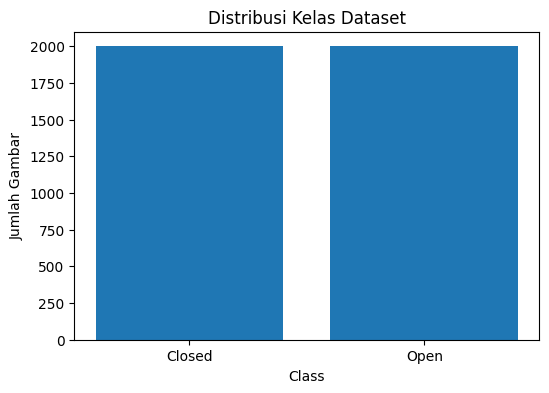

In [ ]:
# EDA Distribusi Kelas
class_counts = df_clean["class"].value_counts().reset_index()
class_counts.columns = ["Class", "Count"]

display(class_counts)

plt.figure(figsize=(6, 4))
plt.bar(class_counts["Class"], class_counts["Count"])
plt.title("Distribusi Kelas Dataset")
plt.xlabel("Class")
plt.ylabel("Jumlah Gambar")
plt.show()

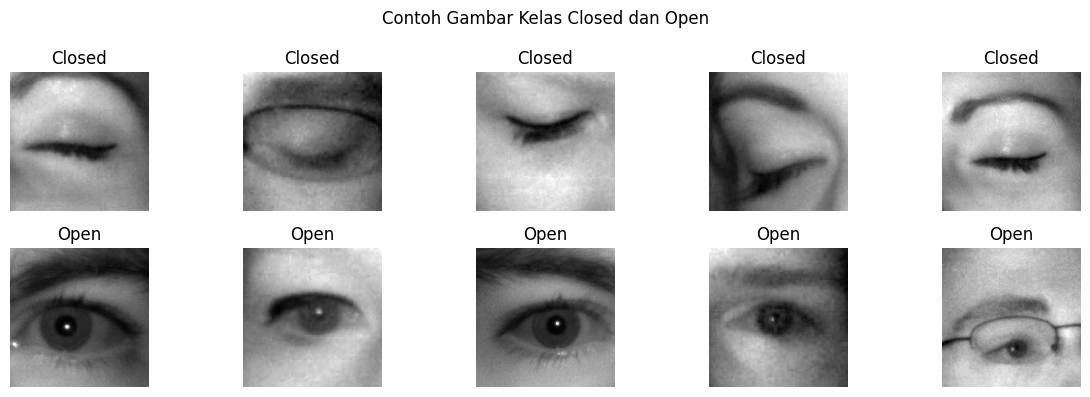

In [ ]:
# EDA Contoh Gambar
plt.figure(figsize=(12, 4))

for i, class_name in enumerate(["Closed", "Open"]):
    sample_paths = df_clean[df_clean["class"] == class_name]["image_path"].head(5).values

    for j, img_path in enumerate(sample_paths):
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        plt.subplot(2, 5, i * 5 + j + 1)
        plt.imshow(img, cmap="gray")
        plt.title(class_name)
        plt.axis("off")

plt.suptitle("Contoh Gambar Kelas Closed dan Open")
plt.tight_layout()
plt.show()

Contoh ukuran gambar:


,height,width,channel
0,108,108,3
1,94,94,3
2,95,95,3
3,96,96,3
4,134,134,3


,height,width,channel,count
0,95,95,3,100
1,85,85,3,95
2,93,93,3,95
3,97,97,3,93
4,86,86,3,89
5,80,80,3,87
6,94,94,3,87
7,84,84,3,80
8,130,130,3,79
9,98,98,3,77


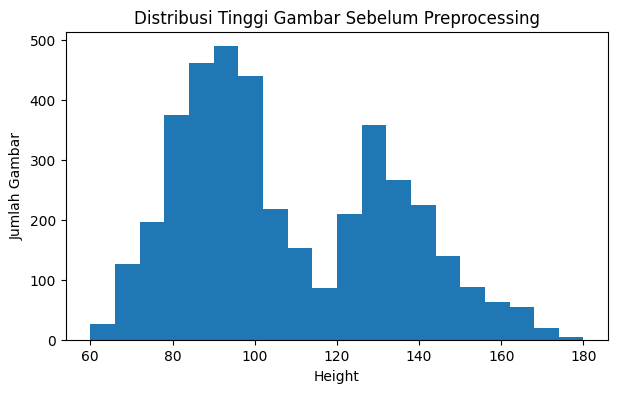

In [ ]:
# EDA Variasi ukuran gambar sebelum preprocessing
print("Contoh ukuran gambar:")
display(image_shapes_df.head())

shape_counts = image_shapes_df.value_counts().reset_index(name="count")
display(shape_counts.head(10))

plt.figure(figsize=(7, 4))
plt.hist(image_shapes_df["height"], bins=20)
plt.title("Distribusi Tinggi Gambar Sebelum Preprocessing")
plt.xlabel("Height")
plt.ylabel("Jumlah Gambar")
plt.show()

,Class,Train,Validation,Test
0,Closed,1400,300,300
1,Open,1401,299,300


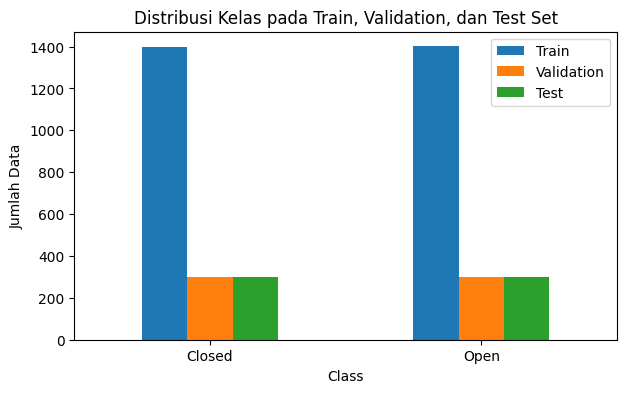

In [ ]:
# EDA Distribusi Split Data (train, validation, test set)
split_distribution = pd.DataFrame({
    "Class": ["Closed", "Open"],
    "Train": [
        np.sum(y_train == 0),
        np.sum(y_train == 1)
    ],
    "Validation": [
        np.sum(y_val == 0),
        np.sum(y_val == 1)
    ],
    "Test": [
        np.sum(y_test == 0),
        np.sum(y_test == 1)
    ]
})

display(split_distribution)

split_distribution.set_index("Class")[["Train", "Validation", "Test"]].plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Distribusi Kelas pada Train, Validation, dan Test Set")
plt.xlabel("Class")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=0)
plt.show()

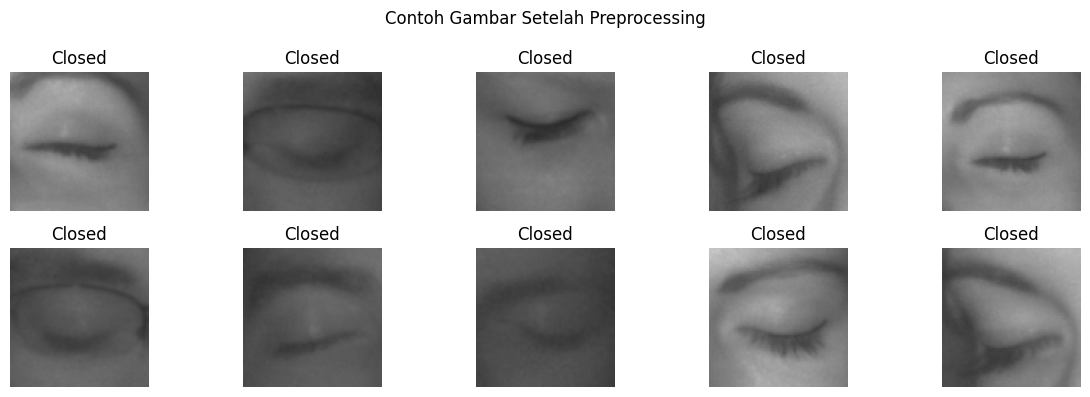

In [ ]:
# EDA Contoh Gambar Setelah Preprocessing
label_map = {
    0: "Closed",
    1: "Open"
}

plt.figure(figsize=(12, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.title(label_map[labels[i]])
    plt.axis("off")

plt.suptitle("Contoh Gambar Setelah Preprocessing")
plt.tight_layout()
plt.show()

In [ ]:
# EDA Shape data hasil preprocessing dan split

shape_summary = pd.DataFrame({
    "Data": ["images", "labels", "x_train", "x_val", "x_test", "y_train", "y_val", "y_test"],
    "Shape": [
        str(images.shape),
        str(labels.shape),
        str(x_train.shape),
        str(x_val.shape),
        str(x_test.shape),
        str(y_train.shape),
        str(y_val.shape),
        str(y_test.shape)
    ]
})

display(shape_summary)

,Data,Shape
0,images,"(4000, 96, 96, 1)"
1,labels,"(4000,)"
2,x_train,"(2801, 96, 96, 1)"
3,x_val,"(599, 96, 96, 1)"
4,x_test,"(600, 96, 96, 1)"
5,y_train,"(2801,)"
6,y_val,"(599,)"
7,y_test,"(600,)"


In [ ]:
# EDA Ringkasan kesiapan data

eda_summary = pd.DataFrame({
    "Aspek": [
        "Jumlah data",
        "Distribusi kelas",
        "Missing value",
        "Duplikasi",
        "Corrupt image",
        "Ukuran input",
        "Normalisasi pixel",
        "Split data"
    ],
    "Hasil": [
        f"{len(df_clean)} gambar",
        "Seimbang antara Closed dan Open",
        "Tidak ditemukan",
        "Tidak ditemukan",
        "Tidak ditemukan",
        "96×96×1",
        "0–1",
        "70% train, 15% validation, 15% test"
    ]
})

display(eda_summary)

,Aspek,Hasil
0,Jumlah data,4000 gambar
1,Distribusi kelas,Seimbang antara Closed dan Open
2,Missing value,Tidak ditemukan
3,Duplikasi,Tidak ditemukan
4,Corrupt image,Tidak ditemukan
5,Ukuran input,96×96×1
6,Normalisasi pixel,0–1
7,Split data,"70% train, 15% validation, 15% test"


# **Load Model**

In [ ]:
model_path = "/content/eye_model_22mei.keras"
model = load_model(model_path, compile=False)
model.summary()

Model: "EyeStateClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eye_input (InputLayer)          │ (None, 96, 96, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ eye_state (Dense)               │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,813,697 (18.36 MB)

 Trainable params: 4,812,737 (18.36 MB)

 Non-trainable params: 960 (3.75 KB)

# **Prediction Preparation**

In [ ]:
# PREDICTION PREPARATION

# Model menghasilkan probabilitas kelas Open
# Karena label AI: 0 = Closed, 1 = Open
# Maka raw probability dari model dibaca sebagai peluang Open

y_val_prob_open = model.predict(x_val, verbose=0).flatten()
y_test_prob_open = model.predict(x_test, verbose=0).flatten()

# Karena fokus proyek adalah mendeteksi kantuk
# maka kelas yang dianggap penting adalah Closed.
# Probabilitas Closed = 1 - probabilitas Open

y_val_prob_closed = 1 - y_val_prob_open
y_test_prob_closed = 1 - y_test_prob_open

# Label asli AI:
# 0 = Closed
# 1 = Open
#
# Untuk evaluasi:
# Closed = 1
# Open = 0

y_val_closed = 1 - y_val
y_test_closed = 1 - y_test

prediction_check = pd.DataFrame({
    "label_asli_AI": y_val[:10],
    "label_closed_format": y_val_closed[:10],
    "probability_open": y_val_prob_open[:10],
    "probability_closed": y_val_prob_closed[:10]
})

display(prediction_check)

,label_asli_AI,label_closed_format,probability_open,probability_closed
0,1,0,9.999893e-01,1.066923e-05
1,0,1,2.239243e-05,9.999776e-01
2,0,1,1.372771e-04,9.998627e-01
3,0,1,3.946477e-08,9.999999e-01
4,0,1,3.808181e-07,9.999996e-01
5,1,0,9.999999e-01,5.960464e-08
6,1,0,9.999948e-01,5.185604e-06
7,1,0,9.995530e-01,4.470348e-04
8,0,1,3.299459e-07,9.999996e-01
9,1,0,9.999916e-01,8.404255e-06


In [ ]:
# THRESHOLD ANALYSIS (buat cari batas terbaik dlm mbedain kelas)

# klo probability_closed >= threshold -> prediksi Closed
# klo probability_closed < threshold  -> prediksi Open

thresholds = np.linspace(0, 1, 1001)

threshold_results = []

for threshold in thresholds:
    y_val_pred = (y_val_prob_closed >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_val_closed, y_val_pred),
        "Precision": precision_score(y_val_closed, y_val_pred, zero_division=0),
        "Recall": recall_score(y_val_closed, y_val_pred, zero_division=0),
        "F1-score": f1_score(y_val_closed, y_val_pred, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

# Threshold terbaik dipilih berdasarkan F1-score tertinggi
best_index = threshold_df["F1-score"].idxmax() #thrs pertama
best_threshold = threshold_df.loc[best_index, "Threshold"]

print("Best Threshold berdasarkan validation set:", best_threshold)

display(threshold_df.loc[[best_index]])

Best Threshold berdasarkan validation set: 0.007


,Threshold,Accuracy,Precision,Recall,F1-score
7,0.007,1.0,1.0,1.0,1.0


In [ ]:
max_f1 = threshold_df["F1-score"].max()

best_thresholds = threshold_df[threshold_df["F1-score"] == max_f1]

print("F1-score tertinggi:", max_f1)
print("Jumlah threshold dengan F1-score tertinggi:", len(best_thresholds))
display(best_thresholds.head())
display(best_thresholds.tail())

F1-score tertinggi: 1.0
Jumlah threshold dengan F1-score tertinggi: 958


,Threshold,Accuracy,Precision,Recall,F1-score
7,0.007,1.0,1.0,1.0,1.0
8,0.008,1.0,1.0,1.0,1.0
9,0.009,1.0,1.0,1.0,1.0
10,0.010,1.0,1.0,1.0,1.0
11,0.011,1.0,1.0,1.0,1.0


,Threshold,Accuracy,Precision,Recall,F1-score
960,0.960,1.0,1.0,1.0,1.0
961,0.961,1.0,1.0,1.0,1.0
962,0.962,1.0,1.0,1.0,1.0
963,0.963,1.0,1.0,1.0,1.0
964,0.964,1.0,1.0,1.0,1.0


# **A/B Testing Threshold**

In [ ]:
# A/B TESTING THRESHOLD

# A = threshold default
# B = threshold hasil threshold analysis

threshold_default = 0.5
threshold_best = best_threshold

y_val_pred_default = (y_val_prob_closed >= threshold_default).astype(int)
y_val_pred_best = (y_val_prob_closed >= threshold_best).astype(int)

ab_testing = pd.DataFrame({
    "Experiment": ["A - Default Threshold", "B - Best Threshold"],
    "Threshold": [threshold_default, threshold_best],
    "Accuracy": [
        accuracy_score(y_val_closed, y_val_pred_default),
        accuracy_score(y_val_closed, y_val_pred_best)
    ],
    "Precision": [
        precision_score(y_val_closed, y_val_pred_default, zero_division=0),
        precision_score(y_val_closed, y_val_pred_best, zero_division=0)
    ],
    "Recall": [
        recall_score(y_val_closed, y_val_pred_default, zero_division=0),
        recall_score(y_val_closed, y_val_pred_best, zero_division=0)
    ],
    "F1-score": [
        f1_score(y_val_closed, y_val_pred_default, zero_division=0),
        f1_score(y_val_closed, y_val_pred_best, zero_division=0)
    ]
})

display(ab_testing)

,Experiment,Threshold,Accuracy,Precision,Recall,F1-score
0,A - Default Threshold,0.500,1.0,1.0,1.0,1.0
1,B - Best Threshold,0.007,1.0,1.0,1.0,1.0


# **Model Evaluation**

In [ ]:
# MODEL EVALUATION

final_threshold = 0.5

# Mengubah probability Closed menjadi prediksi akhir
# Jika probability_closed >= 0.5, maka prediksi = Closed
# Jika probability_closed < 0.5, maka prediksi = Open

y_test_pred = (y_test_prob_closed >= final_threshold).astype(int)

# Metrik evaluasi
accuracy = accuracy_score(y_test_closed, y_test_pred)
precision = precision_score(y_test_closed, y_test_pred, zero_division=0)
recall = recall_score(y_test_closed, y_test_pred, zero_division=0)
f1 = f1_score(y_test_closed, y_test_pred, zero_division=0)

model_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [accuracy, precision, recall, f1]
})

display(model_metrics)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

,Metric,Value
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1-score,1.0


Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000


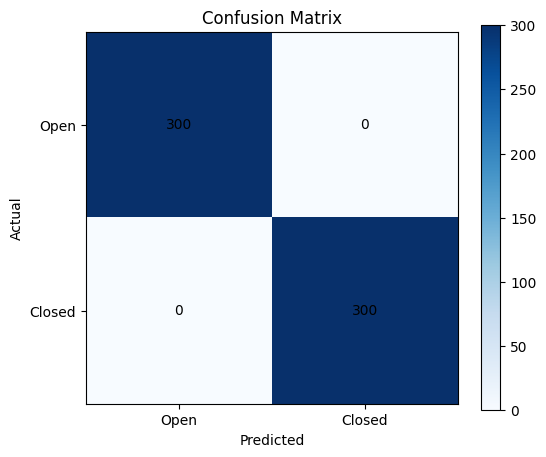

Confusion Matrix:
[[300   0]
 [  0 300]]


In [ ]:
# CONFUSION MATRIX

cm = confusion_matrix(y_test_closed, y_test_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Open", "Closed"])
plt.yticks([0, 1], ["Open", "Closed"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.colorbar()
plt.show()

print("Confusion Matrix:")
print(cm)

# **Jawab**

In [ ]:
# BQ 1 - Kondisi mata sebagai indikator awal kantuk

bq1_summary = pd.DataFrame({
    "Aspek": [
        "Indikator utama",
        "Kondisi normal",
        "Kondisi yang diwaspadai",
        "Bukti evaluasi model"
    ],
    "Hasil": [
        "Kondisi mata Open dan Closed",
        "Open",
        "Closed",
        f"Accuracy {accuracy:.4f}, Recall {recall:.4f}, F1-score {f1:.4f}"
    ]
})

display(bq1_summary)

,Aspek,Hasil
0,Indikator utama,Kondisi mata Open dan Closed
1,Kondisi normal,Open
2,Kondisi yang diwaspadai,Closed
3,Bukti evaluasi model,"Accuracy 1.0000, Recall 1.0000, F1-score 1.0000"


,Class,Count
0,Closed,2000
1,Open,2000


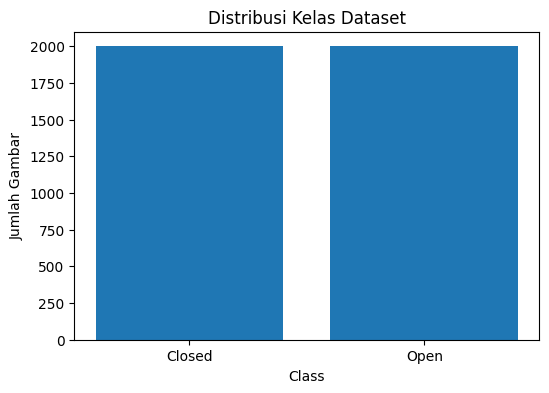

,Class,Train,Validation,Test
0,Closed,1400,300,300
1,Open,1401,299,300


In [ ]:
# BQ 2 - Karakteristik dan keseimbangan dataset

class_counts = df_clean["class"].value_counts().reset_index()
class_counts.columns = ["Class", "Count"]

display(class_counts)

plt.figure(figsize=(6, 4))
plt.bar(class_counts["Class"], class_counts["Count"])
plt.title("Distribusi Kelas Dataset")
plt.xlabel("Class")
plt.ylabel("Jumlah Gambar")
plt.show()

split_distribution = pd.DataFrame({
    "Class": ["Closed", "Open"],
    "Train": [np.sum(y_train == 0), np.sum(y_train == 1)],
    "Validation": [np.sum(y_val == 0), np.sum(y_val == 1)],
    "Test": [np.sum(y_test == 0), np.sum(y_test == 1)]
})

display(split_distribution)

,Tahap,Hasil
0,Resize,96x96 pixel
1,Grayscale,1 channel
2,Normalisasi,0-1
3,Dimensi input,"(96, 96, 1)"
4,Nilai minimum pixel,0.0
5,Nilai maksimum pixel,1.0


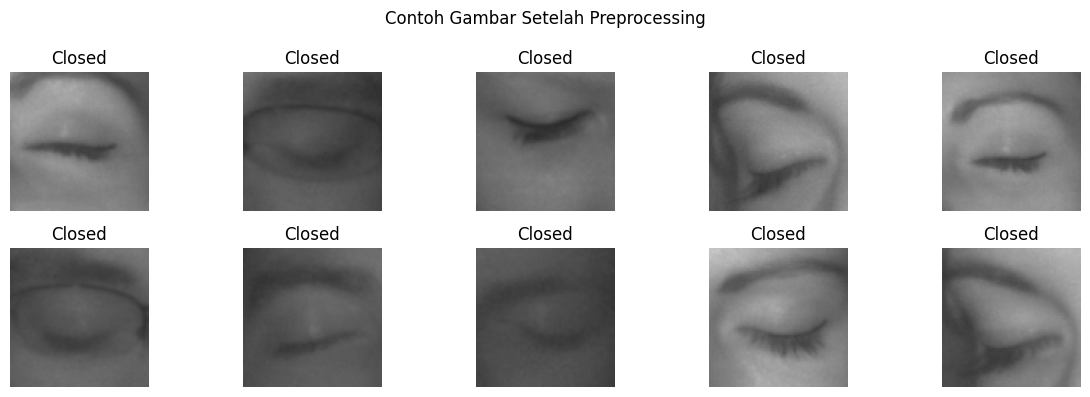

In [ ]:
# BQ 3 - Kesiapan input setelah preprocessing citra

preprocessing_summary = pd.DataFrame({
    "Tahap": [
        "Resize",
        "Grayscale",
        "Normalisasi",
        "Dimensi input",
        "Nilai minimum pixel",
        "Nilai maksimum pixel"
    ],
    "Hasil": [
        "96x96 pixel",
        "1 channel",
        "0-1",
        str(images.shape[1:]),
        images.min(),
        images.max()
    ]
})

display(preprocessing_summary)

plt.figure(figsize=(12, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.title("Closed" if labels[i] == 0 else "Open")
    plt.axis("off")

plt.suptitle("Contoh Gambar Setelah Preprocessing")
plt.tight_layout()
plt.show()

In [ ]:
# RINGKASAN CONFUSION MATRIX

tn, fp, fn, tp = cm.ravel()

confusion_summary = pd.DataFrame({
    "Komponen": [
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive"
    ],
    "Nilai": [tn, fp, fn, tp],
    "Keterangan": [
        "Open diprediksi Open",
        "Open salah diprediksi Closed",
        "Closed salah diprediksi Open",
        "Closed diprediksi Closed"
    ]
})

display(confusion_summary)

,Komponen,Nilai,Keterangan
0,True Negative,300,Open diprediksi Open
1,False Positive,0,Open salah diprediksi Closed
2,False Negative,0,Closed salah diprediksi Open
3,True Positive,300,Closed diprediksi Closed


,Metric,Value
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1-score,1.0


,Komponen,Nilai,Keterangan
0,True Negative,300,Open diprediksi Open
1,False Positive,0,Open salah diprediksi Closed
2,False Negative,0,Closed salah diprediksi Open
3,True Positive,300,Closed diprediksi Closed


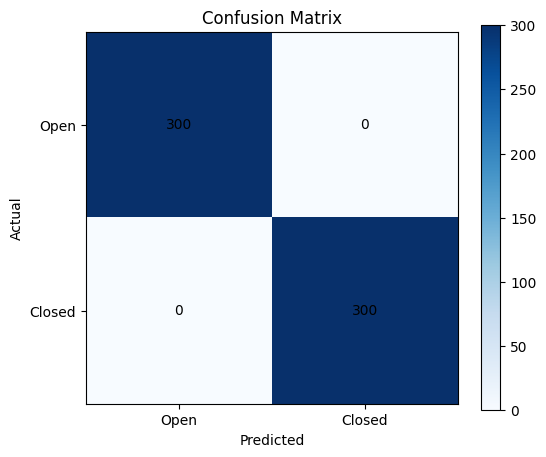

In [ ]:
# BQ 4 - Performa model

display(model_metrics)
display(confusion_summary)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Open", "Closed"])
plt.yticks([0, 1], ["Open", "Closed"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.colorbar()
plt.show()

In [ ]:
# BQ 5 - Threshold Analysis dan A/B Testing

display(ab_testing)

threshold_decision = pd.DataFrame({
    "Komponen": [
        "Threshold default",
        "Threshold hasil analysis",
        "Threshold final yang digunakan"
    ],
    "Nilai": [
        0.5,
        0.004,
        final_threshold
    ]
})

display(threshold_decision)

,Experiment,Threshold,Accuracy,Precision,Recall,F1-score
0,A - Default Threshold,0.500,1.0,1.0,1.0,1.0
1,B - Best Threshold,0.007,1.0,1.0,1.0,1.0


,Komponen,Nilai
0,Threshold default,0.500
1,Threshold hasil analysis,0.004
2,Threshold final yang digunakan,0.500


In [ ]:
# LATENCY TEST (seberapa cepat model mroses gbr)

import time

sample_size = min(100, len(x_test))
x_sample = x_test[:sample_size]

start_time = time.time()
_ = model.predict(x_sample, verbose=0)
end_time = time.time()

total_inference_time = end_time - start_time # total wkt
average_latency = total_inference_time / sample_size # rata-rata wkt
estimated_fps = 1 / average_latency

latency_result = pd.DataFrame({
    "Metric": [
        "Sample Size",
        "Total Inference Time (s)",
        "Average Latency per Image (s)",
        "Estimated FPS"
    ],
    "Value": [
        sample_size,
        total_inference_time,
        average_latency,
        estimated_fps
    ]
})

display(latency_result)

print(f"Jumlah sampel diuji       : {sample_size}")
print(f"Total inference time      : {total_inference_time:.4f} detik")
print(f"Average latency per image : {average_latency:.6f} detik")
print(f"Estimated FPS             : {estimated_fps:.2f}")

,Metric,Value
0,Sample Size,100.000000
1,Total Inference Time (s),0.683720
2,Average Latency per Image (s),0.006837
3,Estimated FPS,146.258729


Jumlah sampel diuji       : 100
Total inference time      : 0.6837 detik
Average latency per image : 0.006837 detik
Estimated FPS             : 146.26


In [ ]:
# BQ 6 - Latency Test

display(latency_result)

avg_latency = latency_result[
    latency_result["Metric"] == "Average Latency per Image (s)"
]["Value"].values[0]

fps_value = latency_result[
    latency_result["Metric"] == "Estimated FPS"
]["Value"].values[0]

latency_summary = pd.DataFrame({
    "Aspek": [
        "Average latency per image",
        "Estimated FPS"
    ],
    "Hasil": [
        f"{avg_latency:.6f} detik",
        f"{fps_value:.2f} FPS",
    ]
})

display(latency_summary)

,Metric,Value
0,Sample Size,100.000000
1,Total Inference Time (s),0.683720
2,Average Latency per Image (s),0.006837
3,Estimated FPS,146.258729


,Aspek,Hasil
0,Average latency per image,0.006837 detik
1,Estimated FPS,146.26 FPS


# Download Data

In [ ]:
# EXPORT CSV UNTUK STREAMLIT

STREAMLIT_DIR = "/content/streamlit_assets"
os.makedirs(STREAMLIT_DIR, exist_ok=True)

# 1. Distribusi kelas dataset
class_counts.to_csv(
    os.path.join(STREAMLIT_DIR, "class_counts.csv"),
    index=False
)

# 2. Distribusi split data
split_distribution.to_csv(
    os.path.join(STREAMLIT_DIR, "split_distribution.csv"),
    index=False
)

# 3. Ringkasan preprocessing / feature engineering
preprocessing_summary.to_csv(
    os.path.join(STREAMLIT_DIR, "preprocessing_summary.csv"),
    index=False
)

# 4. Metrik evaluasi model
model_metrics.to_csv(
    os.path.join(STREAMLIT_DIR, "model_metrics.csv"),
    index=False
)

# 5. Ringkasan confusion matrix
confusion_summary.to_csv(
    os.path.join(STREAMLIT_DIR, "confusion_summary.csv"),
    index=False
)

# 6. Hasil A/B Testing threshold
ab_testing.to_csv(
    os.path.join(STREAMLIT_DIR, "ab_testing.csv"),
    index=False
)

# 7. Keputusan threshold final
threshold_decision.to_csv(
    os.path.join(STREAMLIT_DIR, "threshold_decision.csv"),
    index=False
)

# 8. Hasil latency test
latency_result.to_csv(
    os.path.join(STREAMLIT_DIR, "latency_result.csv"),
    index=False
)

# 9. Ringkasan latency
latency_summary.to_csv(
    os.path.join(STREAMLIT_DIR, "latency_summary.csv"),
    index=False
)

# 10. Data dictionary
data_dictionary.to_csv(
    os.path.join(STREAMLIT_DIR, "data_dictionary.csv"),
    index=False
)

# 11. Ringkasan EDA
eda_summary.to_csv(
    os.path.join(STREAMLIT_DIR, "eda_summary.csv"),
    index=False
)